# Notebook 4 — EDA (the Detailed One)

**Task 2 — From Tables to Notebooks · Qafza Tech MLOps Training 2026/2027**

**Goal:** really get to know the training data — types, missingness, distributions, relationships to the label — so Notebook 5's feature choices are backed by something we actually looked at, not guesswork.

**Rule for this whole notebook: `train.csv` only.** We do not open `val.csv` or `test.csv` here — not even to peek.

**What we'll do:**
1. Data types, shape, memory
2. Missing values — how much, and does the missingness itself mean something
3. Numerical features — stats, distributions, outliers
4. Categorical features — cardinality, rare categories
5. Relationships to the label
6. Dates — seasonality, weekday effects
7. Geography — customer/seller state
8. Write down the findings


## 0. Load — Training Split Only


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ARTIFACTS_DIR = Path("artifacts/tables")
FIGURES_DIR = Path("artifacts/figures")
REPORTS_DIR = Path("artifacts/reports")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

DATE_COLS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

train_df = pd.read_csv(ARTIFACTS_DIR / "train.csv", parse_dates=DATE_COLS)
print("train_df:", train_df.shape)

sns.set_theme(style="whitegrid")
findings = []  # we will keep appending short notes here, then write them all out at the end


train_df: (67529, 29)


## 1. Data Types, Shape, Memory


In [2]:
print(f"Shape: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns")
print(f"Memory: {train_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()
train_df.dtypes.to_frame("dtype")

Shape: 67,529 rows x 29 columns
Memory: 46.4 MB



,dtype
order_id,str
customer_id,str
order_status,str
order_purchase_timestamp,datetime64[us]
order_approved_at,datetime64[us]
order_delivered_carrier_date,datetime64[us]
order_delivered_customer_date,datetime64[us]
order_estimated_delivery_date,datetime64[us]
customer_city,str
customer_state,str


In [3]:
numeric_cols = train_df.select_dtypes(include="number").columns.tolist()
date_cols_present = [c for c in DATE_COLS if c in train_df.columns]
categorical_cols = train_df.select_dtypes(include="object").columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in ["order_id", "customer_id"]]

print("Numerical  :", numeric_cols)
print()
print("Categorical:", categorical_cols)
print()
print("Dates      :", date_cols_present)


Numerical  : ['customer_zip_code_prefix', 'n_items', 'n_distinct_products', 'n_distinct_sellers', 'total_price', 'total_freight_value', 'avg_freight_value', 'total_weight_g', 'max_product_length_cm', 'max_product_height_cm', 'max_product_width_cm', 'total_payment_value', 'n_payment_transactions', 'max_payment_installments', 'is_late']

Categorical: ['order_status', 'customer_city', 'customer_state', 'main_product_category', 'main_seller_state', 'main_seller_city', 'main_payment_type']

Dates      : ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


C:\Users\SKY\AppData\Local\Temp\ipykernel_13912\4068770708.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include="object").columns.tolist()


## 2. Missing Values


In [4]:
missing = train_df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(train_df) * 100).round(2)
missing_summary = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
missing_summary = missing_summary[missing_summary["n_missing"] > 0]
missing_summary


,n_missing,pct_missing
main_product_category,1223,1.81
max_product_width_cm,16,0.02
max_product_length_cm,16,0.02
max_product_height_cm,16,0.02
order_approved_at,14,0.02
main_payment_type,1,0.00
total_payment_value,1,0.00
max_payment_installments,1,0.00
n_payment_transactions,1,0.00
order_delivered_carrier_date,1,0.00


**Is the missingness itself meaningful?** Worth checking directly rather than assuming — e.g. do orders with a missing `main_product_category` or missing item stats also tend to be missing `n_items` (meaning: the order simply had no matching item row, which we already explained in Notebook 1)?


In [5]:
if "n_items" in train_df.columns:
    no_items = train_df["n_items"].isna()
    print(f"Orders with no item rows at all: {no_items.sum():,} ({no_items.mean():.2%} of train)")
    print(f"Late rate for those orders     : {train_df.loc[no_items, 'is_late'].mean():.2%}")
    print(f"Late rate for the rest         : {train_df.loc[~no_items, 'is_late'].mean():.2%}")

findings.append(
    f"Missingness: {missing_summary.shape[0]} columns have missing values. "
    "Orders with no matching order_items row explain most of the missing item/product/seller "
    "fields — these are largely orders that never really shipped. Compare their late-rate above "
    "against the rest to judge whether they behave differently."
)


Orders with no item rows at all: 0 (0.00% of train)
Late rate for those orders     : nan%
Late rate for the rest         : 9.03%


## 3. Numerical Features — Stats, Distributions, Outliers


In [6]:
numeric_for_stats = [c for c in numeric_cols if c not in ["is_late"]]
train_df[numeric_for_stats].describe().T


,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,67529.0,36010.051889,29908.242352,1004.00,12061.00,25959.00,60360.00,99980.00
n_items,67529.0,1.142072,0.541640,1.00,1.00,1.00,1.00,21.00
n_distinct_products,67529.0,1.037702,0.222199,1.00,1.00,1.00,1.00,7.00
n_distinct_sellers,67529.0,1.012054,0.114815,1.00,1.00,1.00,1.00,5.00
total_price,67529.0,135.888797,205.194019,2.29,45.90,85.00,149.90,13440.00
total_freight_value,67529.0,22.245936,20.002594,0.00,14.10,16.79,23.70,1002.29
avg_freight_value,67529.0,19.640187,14.382949,0.00,13.44,16.11,20.29,338.30
total_weight_g,67529.0,2465.508389,4909.466159,0.00,300.00,800.00,2150.00,184400.00
max_product_length_cm,67513.0,30.724453,16.480326,7.00,18.00,25.00,40.00,105.00
max_product_height_cm,67513.0,16.799579,13.693209,2.00,8.00,13.00,20.00,105.00


In [7]:
skew = train_df[numeric_for_stats].skew().sort_values(ascending=False)
print("Skewness (higher = more right-skewed / long tail):")
skew


Skewness (higher = more right-skewed / long tail):


n_payment_transactions      22.419509
total_price                 10.718895
n_distinct_sellers          10.524938
total_payment_value         10.149318
total_freight_value          8.581743
n_items                      8.107162
n_distinct_products          7.677312
total_weight_g               6.644615
avg_freight_value            5.549942
max_product_height_cm        2.211511
max_product_width_cm         1.721737
max_product_length_cm        1.717399
max_payment_installments     1.592665
customer_zip_code_prefix     0.739782
dtype: float64

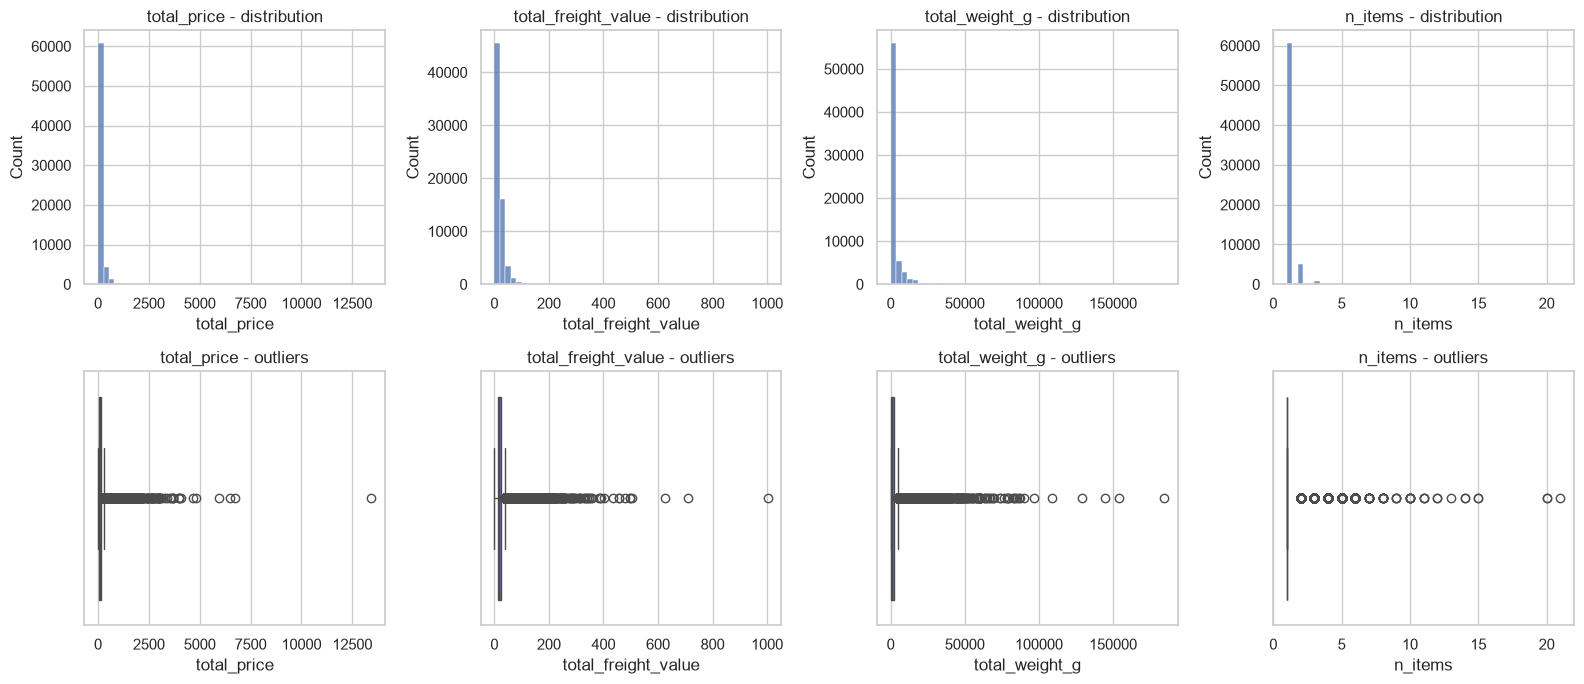

In [8]:
plot_cols = [c for c in ["total_price", "total_freight_value", "total_weight_g", "n_items"] if c in train_df.columns]

fig, axes = plt.subplots(2, len(plot_cols), figsize=(4 * len(plot_cols), 7))
for i, col in enumerate(plot_cols):
    sns.histplot(train_df[col].dropna(), bins=50, ax=axes[0, i])
    axes[0, i].set_title(f"{col} - distribution")
    sns.boxplot(x=train_df[col].dropna(), ax=axes[1, i])
    axes[1, i].set_title(f"{col} - outliers")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_distributions.png", dpi=120)
plt.show()


In [9]:
# Ranges that make no sense are worth calling out explicitly, not just eyeballing a chart.
for col in plot_cols:
    zero_or_neg = (train_df[col] <= 0).sum()
    print(f"{col:22s} min={train_df[col].min():>12.2f}  max={train_df[col].max():>14.2f}  <=0 count: {zero_or_neg}")

findings.append(
    "Numerical features are right-skewed (see skew table) — price, freight, and weight all have "
    "long tails from a small number of large/multi-item orders. Worth remembering this when "
    "picking a model or a scaler in Notebook 5: tree-based models don't care about skew, "
    "linear models generally do."
)


total_price            min=        2.29  max=      13440.00  <=0 count: 0
total_freight_value    min=        0.00  max=       1002.29  <=0 count: 10
total_weight_g         min=        0.00  max=     184400.00  <=0 count: 16
n_items                min=        1.00  max=         21.00  <=0 count: 0


## 4. Categorical Features — Cardinality, Rare Categories


In [10]:
for col in categorical_cols:
    n_unique = train_df[col].nunique(dropna=True)
    print(f"{col:24s} {n_unique:>4} distinct values")


order_status                1 distinct values
customer_city            3747 distinct values
customer_state             27 distinct values
main_product_category      71 distinct values
main_seller_state          22 distinct values
main_seller_city          490 distinct values
main_payment_type           4 distinct values


Top 15 product categories:


main_product_category
bed_bath_table           6586
sports_leisure           5602
health_beauty            5373
computers_accessories    4778
furniture_decor          4532
housewares               3515
watches_gifts            3271
telephony                3065
toys                     2989
cool_stuff               2944
garden_tools             2629
auto                     2408
perfumery                2284
baby                     1839
electronics              1754
Name: count, dtype: int64

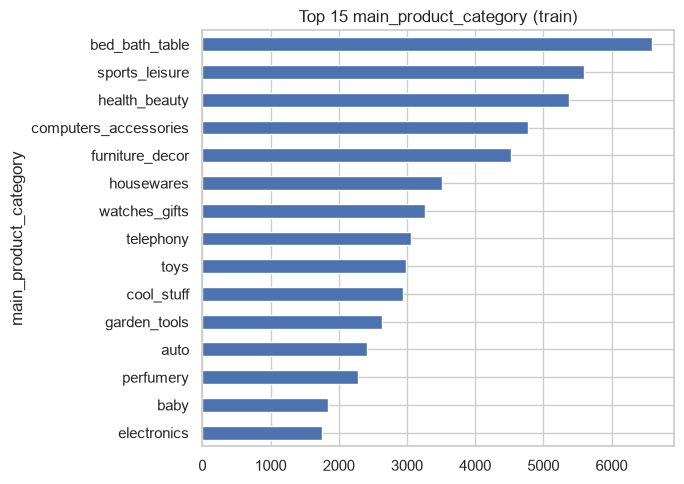


Categories with fewer than 50 orders in train: 17 out of 71


In [11]:
if "main_product_category" in train_df.columns:
    top_categories = train_df["main_product_category"].value_counts()
    print("Top 15 product categories:")
    display(top_categories.head(15))

    fig, ax = plt.subplots(figsize=(7, 5))
    top_categories.head(15).sort_values().plot(kind="barh", ax=ax)
    ax.set_title("Top 15 main_product_category (train)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "top_product_categories.png", dpi=120)
    plt.show()

    n_rare = (top_categories < 50).sum()
    print(f"\nCategories with fewer than 50 orders in train: {n_rare} out of {len(top_categories)}")


In [12]:
if "main_payment_type" in train_df.columns:
    print(train_df["main_payment_type"].value_counts())

findings.append(
    "main_product_category has high cardinality with a long tail of rare categories — "
    "candidate for grouping rare ones into an 'other' bucket in Notebook 5, rather than "
    "one-hot-encoding every single category. main_payment_type and the state columns are "
    "low-cardinality and can be one-hot encoded as-is."
)


main_payment_type
credit_card    50728
boleto         13901
voucher         2201
debit_card       698
Name: count, dtype: int64


## 5. Relationships to the Label

`is_late` is the target — everything from here on is "does this feature move with the label?"


In [13]:
overall_rate = train_df["is_late"].mean()
print(f"Overall late rate (train): {overall_rate:.2%}")
print()

if "main_payment_type" in train_df.columns:
    by_payment = train_df.groupby("main_payment_type")["is_late"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    print("Late rate by main_payment_type:")
    display(by_payment)


Overall late rate (train): 9.03%

Late rate by main_payment_type:


,mean,count
main_payment_type,,
debit_card,0.098854,698
boleto,0.094094,13901
credit_card,0.089655,50728
voucher,0.077238,2201


In [14]:
if "main_product_category" in train_df.columns:
    by_category = (
        train_df.groupby("main_product_category")["is_late"]
        .agg(["mean", "count"])
        .query("count >= 50")
        .sort_values("mean", ascending=False)
    )
    print("Late rate by main_product_category (categories with >= 50 orders only):")
    display(by_category.head(10))
    display(by_category.tail(10))


Late rate by main_product_category (categories with >= 50 orders only):


,mean,count
main_product_category,,
audio,0.162602,246
construction_tools_construction,0.144444,270
construction_tools_lights,0.142857,56
fashion_underwear_beach,0.135922,103
christmas_supplies,0.125000,88
home_confort,0.119048,294
electronics,0.117446,1754
baby,0.109299,1839
musical_instruments,0.108642,405


,mean,count
main_product_category,,
agro_industry_and_commerce,0.062500,112
home_appliances,0.061927,436
air_conditioning,0.056180,178
fixed_telephony,0.054217,166
luggage_accessories,0.053165,790
market_place,0.048673,226
fashion_male_clothing,0.044444,90
computers,0.043796,137
construction_tools_safety,0.042254,71


In [15]:
corr_cols = [c for c in numeric_for_stats if c != "is_late"]
correlations = train_df[corr_cols + ["is_late"]].corr()["is_late"].drop("is_late").sort_values(key=abs, ascending=False)
print("Correlation of each numeric feature with is_late:")
correlations


Correlation of each numeric feature with is_late:


avg_freight_value           0.069311
total_freight_value         0.046597
customer_zip_code_prefix    0.040422
n_distinct_sellers         -0.025871
total_payment_value         0.024776
n_distinct_products        -0.021589
total_price                 0.021336
total_weight_g              0.019402
max_product_length_cm       0.018517
max_payment_installments    0.017183
n_items                    -0.016130
max_product_height_cm       0.013254
max_product_width_cm        0.008100
n_payment_transactions     -0.005890
Name: is_late, dtype: float64

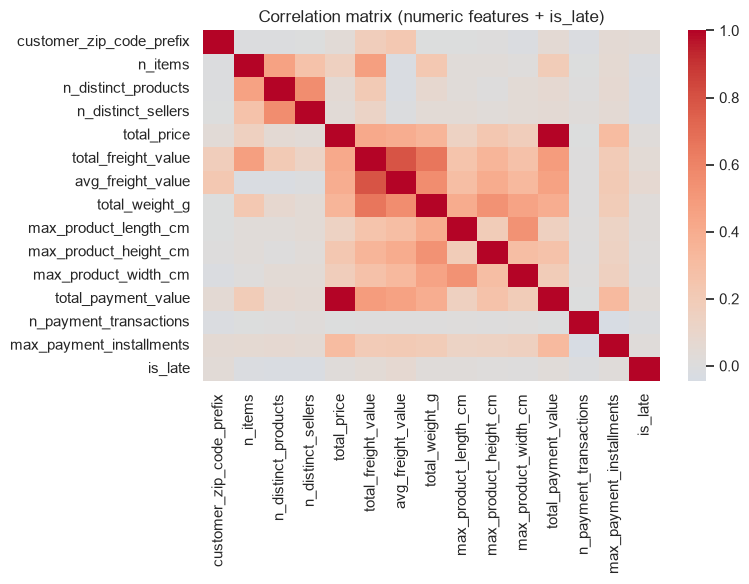

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(train_df[corr_cols + ["is_late"]].corr(), cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlation matrix (numeric features + is_late)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=120)
plt.show()

findings.append(
    "No single numeric feature is strongly correlated with is_late on its own (see correlation "
    "table) — this is a problem where the model likely needs to combine several weak signals "
    "rather than lean on one dominant feature. Some product categories and payment types show "
    "a noticeably higher or lower late-rate than the overall average, so they carry real signal."
)


## 6. Dates — Seasonality, Weekday Effects, and the "Promised Days"


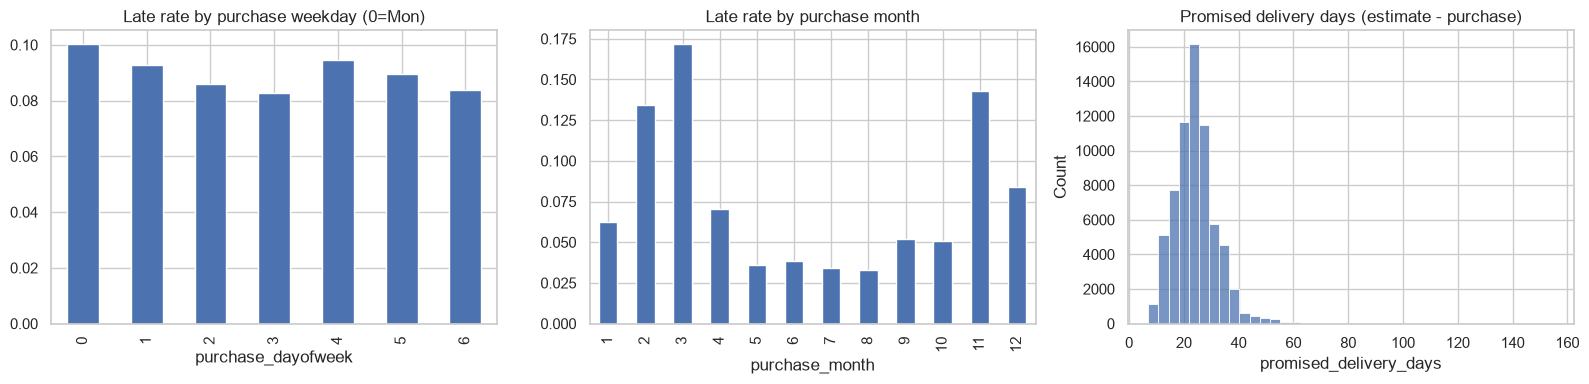

In [17]:
train_df["purchase_dayofweek"] = train_df["order_purchase_timestamp"].dt.dayofweek
train_df["purchase_month"] = train_df["order_purchase_timestamp"].dt.month
train_df["promised_delivery_days"] = (
    train_df["order_estimated_delivery_date"] - train_df["order_purchase_timestamp"]
).dt.days

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

train_df.groupby("purchase_dayofweek")["is_late"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Late rate by purchase weekday (0=Mon)")

train_df.groupby("purchase_month")["is_late"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Late rate by purchase month")

sns.histplot(train_df["promised_delivery_days"].dropna(), bins=40, ax=axes[2])
axes[2].set_title("Promised delivery days (estimate - purchase)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "date_effects.png", dpi=120)
plt.show()


In [18]:
# Does a tighter promised window correlate with being late more often?
promised_vs_late = train_df.groupby(pd.cut(train_df["promised_delivery_days"], bins=[0, 7, 14, 21, 30, 200]))["is_late"].agg(["mean", "count"])
print(promised_vs_late)

findings.append(
    "purchase_month shows visible seasonal swings in the late rate (worth double-checking against "
    "known Brazilian shopping peaks, e.g. Black Friday). promised_delivery_days looks like one of "
    "the more informative numeric signals -- orders with a shorter promised window trend towards "
    "a higher late rate."
)


                            mean  count
promised_delivery_days                 
(0, 7]                  0.274194     62
(7, 14]                 0.058994   6204
(14, 21]                0.104948  19400
(21, 30]                0.096920  29736
(30, 200]               0.065556  12127


## 7. Geography — Customer & Seller State


Late rate by customer_state:


,mean,count
customer_state,,
AL,0.278523,298
MA,0.215328,548
CE,0.182489,948
RR,0.172414,29
SE,0.170732,246
PI,0.166667,348
RJ,0.165867,8965
BA,0.149978,2307
PA,0.133705,718


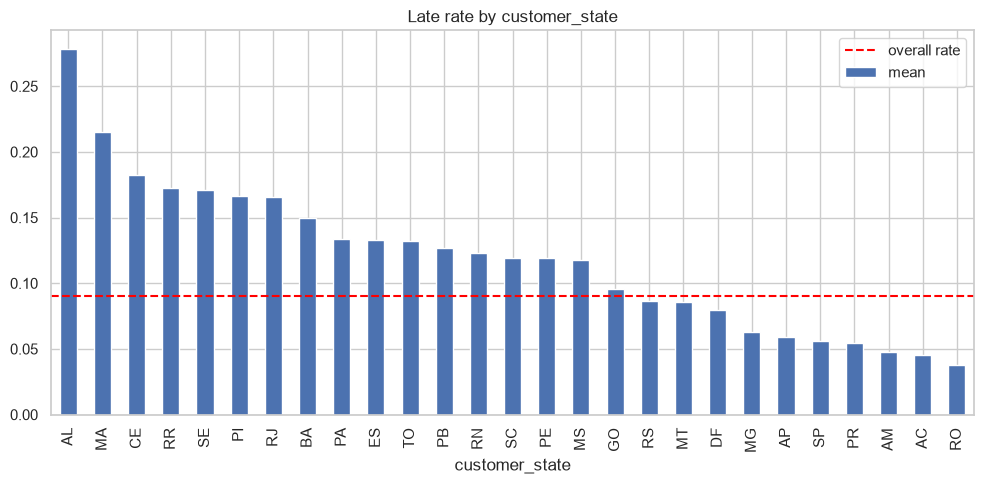

In [19]:
if "customer_state" in train_df.columns:
    by_customer_state = train_df.groupby("customer_state")["is_late"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    print("Late rate by customer_state:")
    display(by_customer_state)

    fig, ax = plt.subplots(figsize=(10, 5))
    by_customer_state["mean"].plot(kind="bar", ax=ax)
    ax.axhline(overall_rate, color="red", linestyle="--", label="overall rate")
    ax.set_title("Late rate by customer_state")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "late_rate_by_state.png", dpi=120)
    plt.show()


In [20]:
if "main_seller_state" in train_df.columns:
    same_state = (train_df["customer_state"] == train_df["main_seller_state"])
    print("Same-state orders (customer state == seller state):", same_state.mean().round(3))
    print()
    print("Late rate when customer and seller are in the same state:", train_df.loc[same_state, "is_late"].mean().round(3))
    print("Late rate when they are in different states           :", train_df.loc[~same_state, "is_late"].mean().round(3))

findings.append(
    "Late rate varies noticeably by customer_state -- Brazil is huge, and some states are simply "
    "farther from the main seller hubs. Whether customer and seller share a state also separates "
    "the late rate, which hints that a same_state or distance-like feature could help in "
    "Notebook 5."
)


Same-state orders (customer state == seller state): 0.342

Late rate when customer and seller are in the same state: 0.055
Late rate when they are in different states           : 0.109


## 8. Write Down the Findings

This is the whole point of the notebook — a short, honest summary of what we found, saved so Notebook 5 doesn't have to re-derive it from scratch.


In [21]:
findings_text = "# EDA Findings -- Notebook 4\n\n" + "\n\n".join(f"- {f}" for f in findings)
findings_text += f"\n\n---\nOverall late rate in train: {overall_rate:.2%}\n"

with open(REPORTS_DIR / "eda_findings.md", "w") as f:
    f.write(findings_text)

print(findings_text)


# EDA Findings -- Notebook 4

- Missingness: 10 columns have missing values. Orders with no matching order_items row explain most of the missing item/product/seller fields — these are largely orders that never really shipped. Compare their late-rate above against the rest to judge whether they behave differently.

- Numerical features are right-skewed (see skew table) — price, freight, and weight all have long tails from a small number of large/multi-item orders. Worth remembering this when picking a model or a scaler in Notebook 5: tree-based models don't care about skew, linear models generally do.

- main_product_category has high cardinality with a long tail of rare categories — candidate for grouping rare ones into an 'other' bucket in Notebook 5, rather than one-hot-encoding every single category. main_payment_type and the state columns are low-cardinality and can be one-hot encoded as-is.

- No single numeric feature is strongly correlated with is_late on its own (see correlatio

## Recap

**Decisions this EDA points to, going into Notebook 5:**
- Use `promised_delivery_days`, `purchase_dayofweek`, `purchase_month` as engineered date features.
- One-hot encode `main_payment_type`, `customer_state`, `main_seller_state` directly (low cardinality).
- For `main_product_category`, cap to the most frequent categories and bucket the rest as `other` before encoding (long tail of rare categories).
- Numeric features are skewed — fine for a tree-based model; would need transforming for a linear one.
- Missing item/product fields mostly trace back to orders with no item rows — impute rather than drop, since dropping would bias the training set.

**Artifacts saved:** all charts in `artifacts/figures/`, findings summary in `artifacts/reports/eda_findings.md`.

**Next up — Notebook 5:** build the actual features, fit every transformer on `train` only, and save them.
